# tuned — DQN/DDQN at each environment's tuned LR vs. Random

Runs DQN and DDQN at the best learning rate found for each agent in
`experiments/tuning`, across every tuning environment (Acrobot, Cartpole, Catch,
MountainCar, and Pinball's box/easy/empty/medium settings), 100 seeds each,
against a 100-seed Random baseline. Seeds are offset by 10 (`[10, 109]`) so none
of the seeds used to tune the LR are reused here. For every environment: a
learning curve comparing DQN, DDQN and Random over the agent's lifetime, plus
one grid figure combining all eight. Catch is a continuing task with no episode
to derive a return from, so it plots an EMA (beta=0.99) of reward instead.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

_HERE = Path.cwd()
_EXP_DIR = _HERE if (_HERE / "config.py").exists() else Path("experiments/tuned")
sys.path.insert(0, str(_EXP_DIR))
sys.path.insert(0, str(_EXP_DIR.resolve().parents[1]))

from experiment import load_result, load_runs
from analysis.plotting import (
    ema_reward_grids_for,
    plot_mean_ci,
    seed_grids_for,
    style,
)

HERE = Path.cwd()
RESULTS = HERE / "results" if (HERE / "results").exists() else Path("experiments/tuned/results")
PLOTS_DIR = RESULTS.parent / "plots"
PLOTS_DIR.mkdir(exist_ok=True)


from config import EXPERIMENT


def grid_for(component, n=500):
    """A shared [0, total_steps] timestep grid from any run's length."""
    df = load_runs(EXPERIMENT, component)
    total_steps = len(load_result(EXPERIMENT, component, df["run_id"][0])["reward"])
    return np.linspace(0, total_steps, n)


ENVS = [
    {"key": "cartpole", "title": "Cartpole",
     "metric": "return", "ylim": (0, 500)},
    {"key": "acrobot", "title": "Acrobot",
     "metric": "return", "ylim": (-500, 0)},
    {"key": "mountaincar", "title": "MountainCar",
     "metric": "return", "ylim": (-1000, 0)},
    {"key": "catch", "title": "Catch",
     "metric": "reward", "ylim": None},
    {"key": "pinball_box", "title": "Pinball (Box)",
     "metric": "return", "ylim": (-1000, 0)},
    {"key": "pinball_easy", "title": "Pinball (Easy)",
     "metric": "return", "ylim": (-1000, 0)},
    {"key": "pinball_empty", "title": "Pinball (Empty)",
     "metric": "return", "ylim": (-1000, 0)},
    {"key": "pinball_medium", "title": "Pinball (Medium)",
     "metric": "return", "ylim": (-1000, 0)},
]

In [2]:
def load_series(key, metric):
    """Random/DQN/DDQN return- or reward-stacks for one environment.

    Each component gets its own timestep grid, matching ``experiments/tuning``'s
    learning-curve cell. A component with no completed runs yet is skipped.
    """
    curve_fn = seed_grids_for if metric == "return" else ema_reward_grids_for
    names = [
        ("Random", "tab:red", "random"),
        ("DQN", "tab:blue", "dqn"),
        ("DDQN", "tab:green", "ddqn"),
    ]
    series = []
    for label, color, name in names:
        component = f"{name}_{key}"
        if load_runs(EXPERIMENT, component).is_empty():
            print(f"[{key}] skipping {label}: no completed runs yet")
            continue
        grid = grid_for(component)
        stack = curve_fn(EXPERIMENT, component, grid)
        series.append((label, color, grid, stack))
    return series


def plot_series(ax, series):
    for label, color, grid, stack in series:
        plot_mean_ci(ax, grid, stack, label, color)


def set_timestep_xticks(ax, series):
    """Show only 0 and the max timestep on a learning curve's x-axis."""
    max_timestep = max(grid[-1] for _, _, grid, _ in series)
    ax.set_xticks([0, max_timestep])


def analyze(key, title, metric, ylim):
    """DQN vs. DDQN vs. Random learning curve for one environment.

    Saves ``<key>_learning_curve.pdf`` to ``PLOTS_DIR``.
    """
    series = load_series(key, metric)
    ylabel = "Return" if metric == "return" else "Reward\n(EMA)"

    fig, ax = plt.subplots(figsize=(9, 6))   # 2:3 height:width
    plot_series(ax, series)
    ax.set_title(f"{title} (100 seeds, 95% CI)")
    ax.legend(loc="lower right", frameon=False)
    style(ax, ylim=ylim, ylabel=ylabel)
    set_timestep_xticks(ax, series)
    fig.tight_layout()
    plt.show()

    fig.savefig(PLOTS_DIR / f"{key}_learning_curve.pdf", bbox_inches="tight")

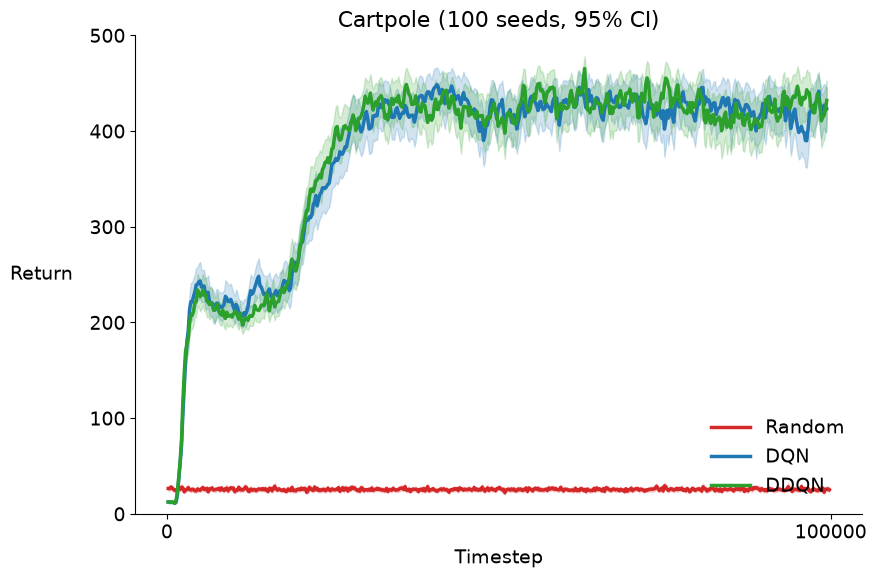

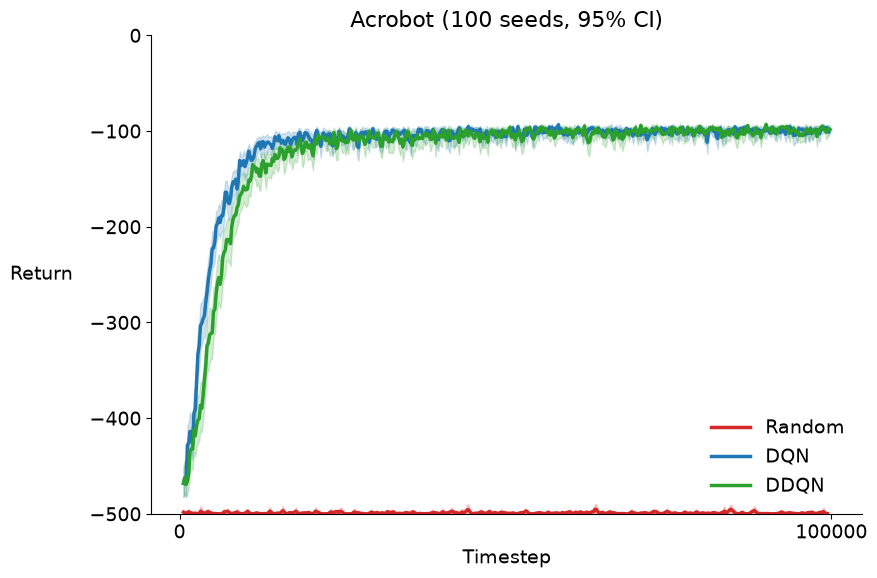

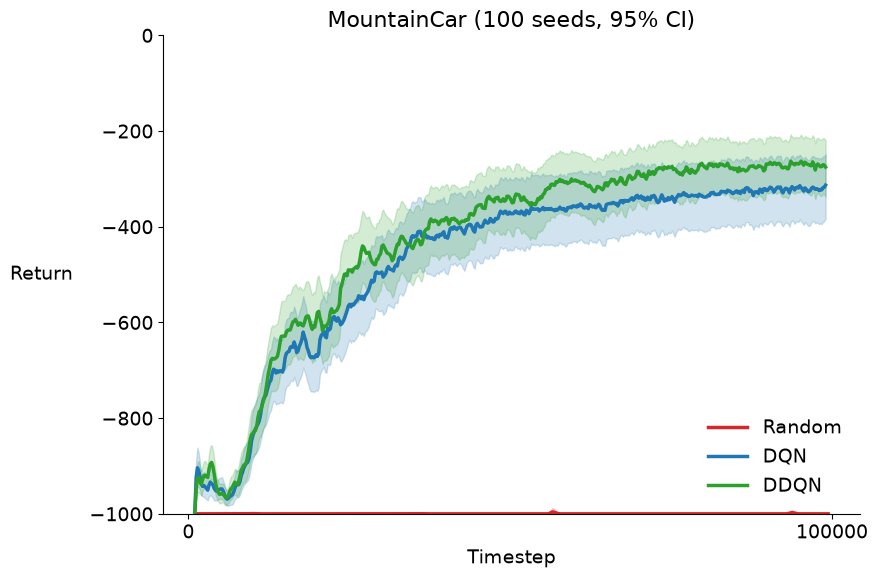

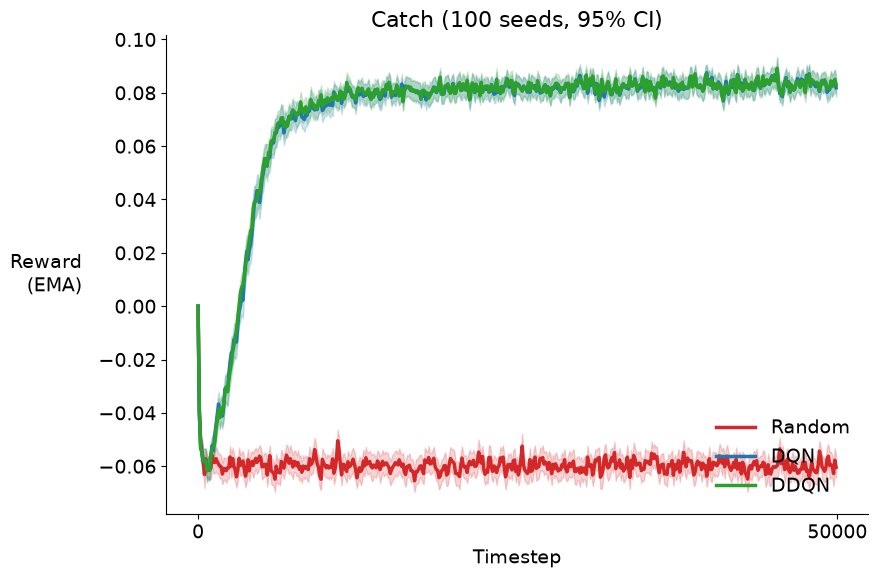

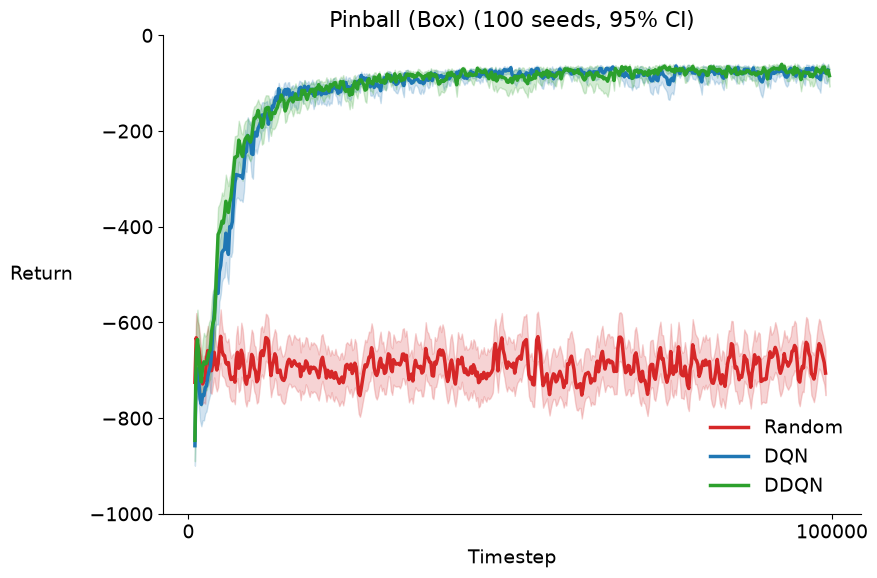

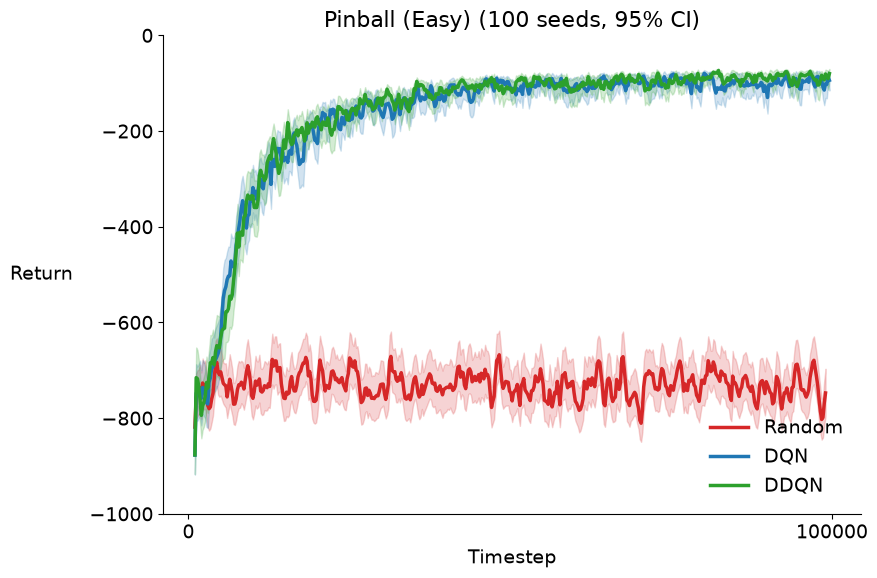

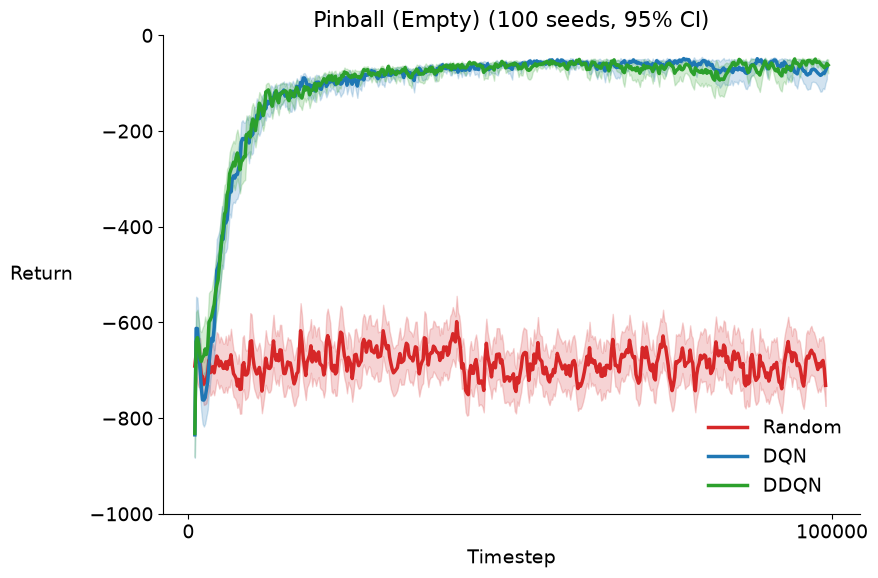

[pinball_medium] skipping Random: no completed runs yet


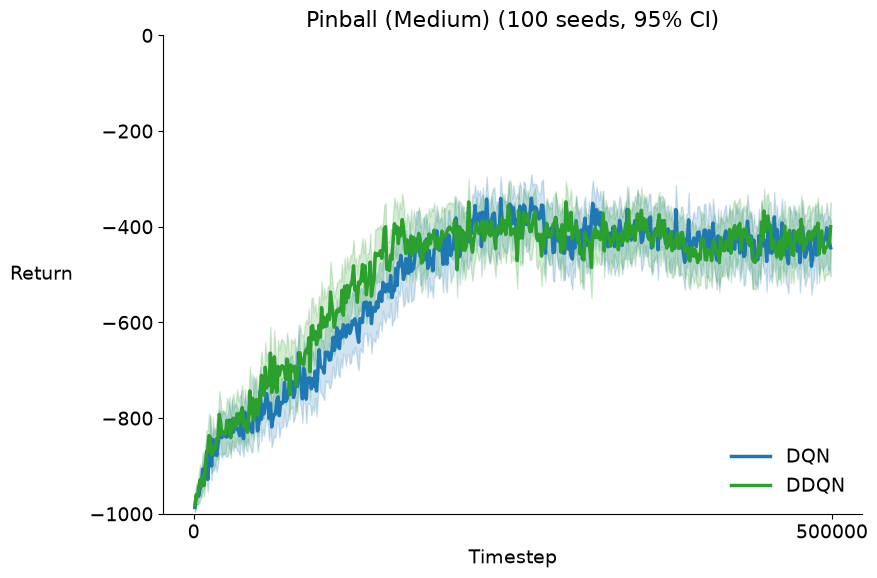

In [3]:
for env in ENVS:
    analyze(**env)

[pinball_medium] skipping Random: no completed runs yet


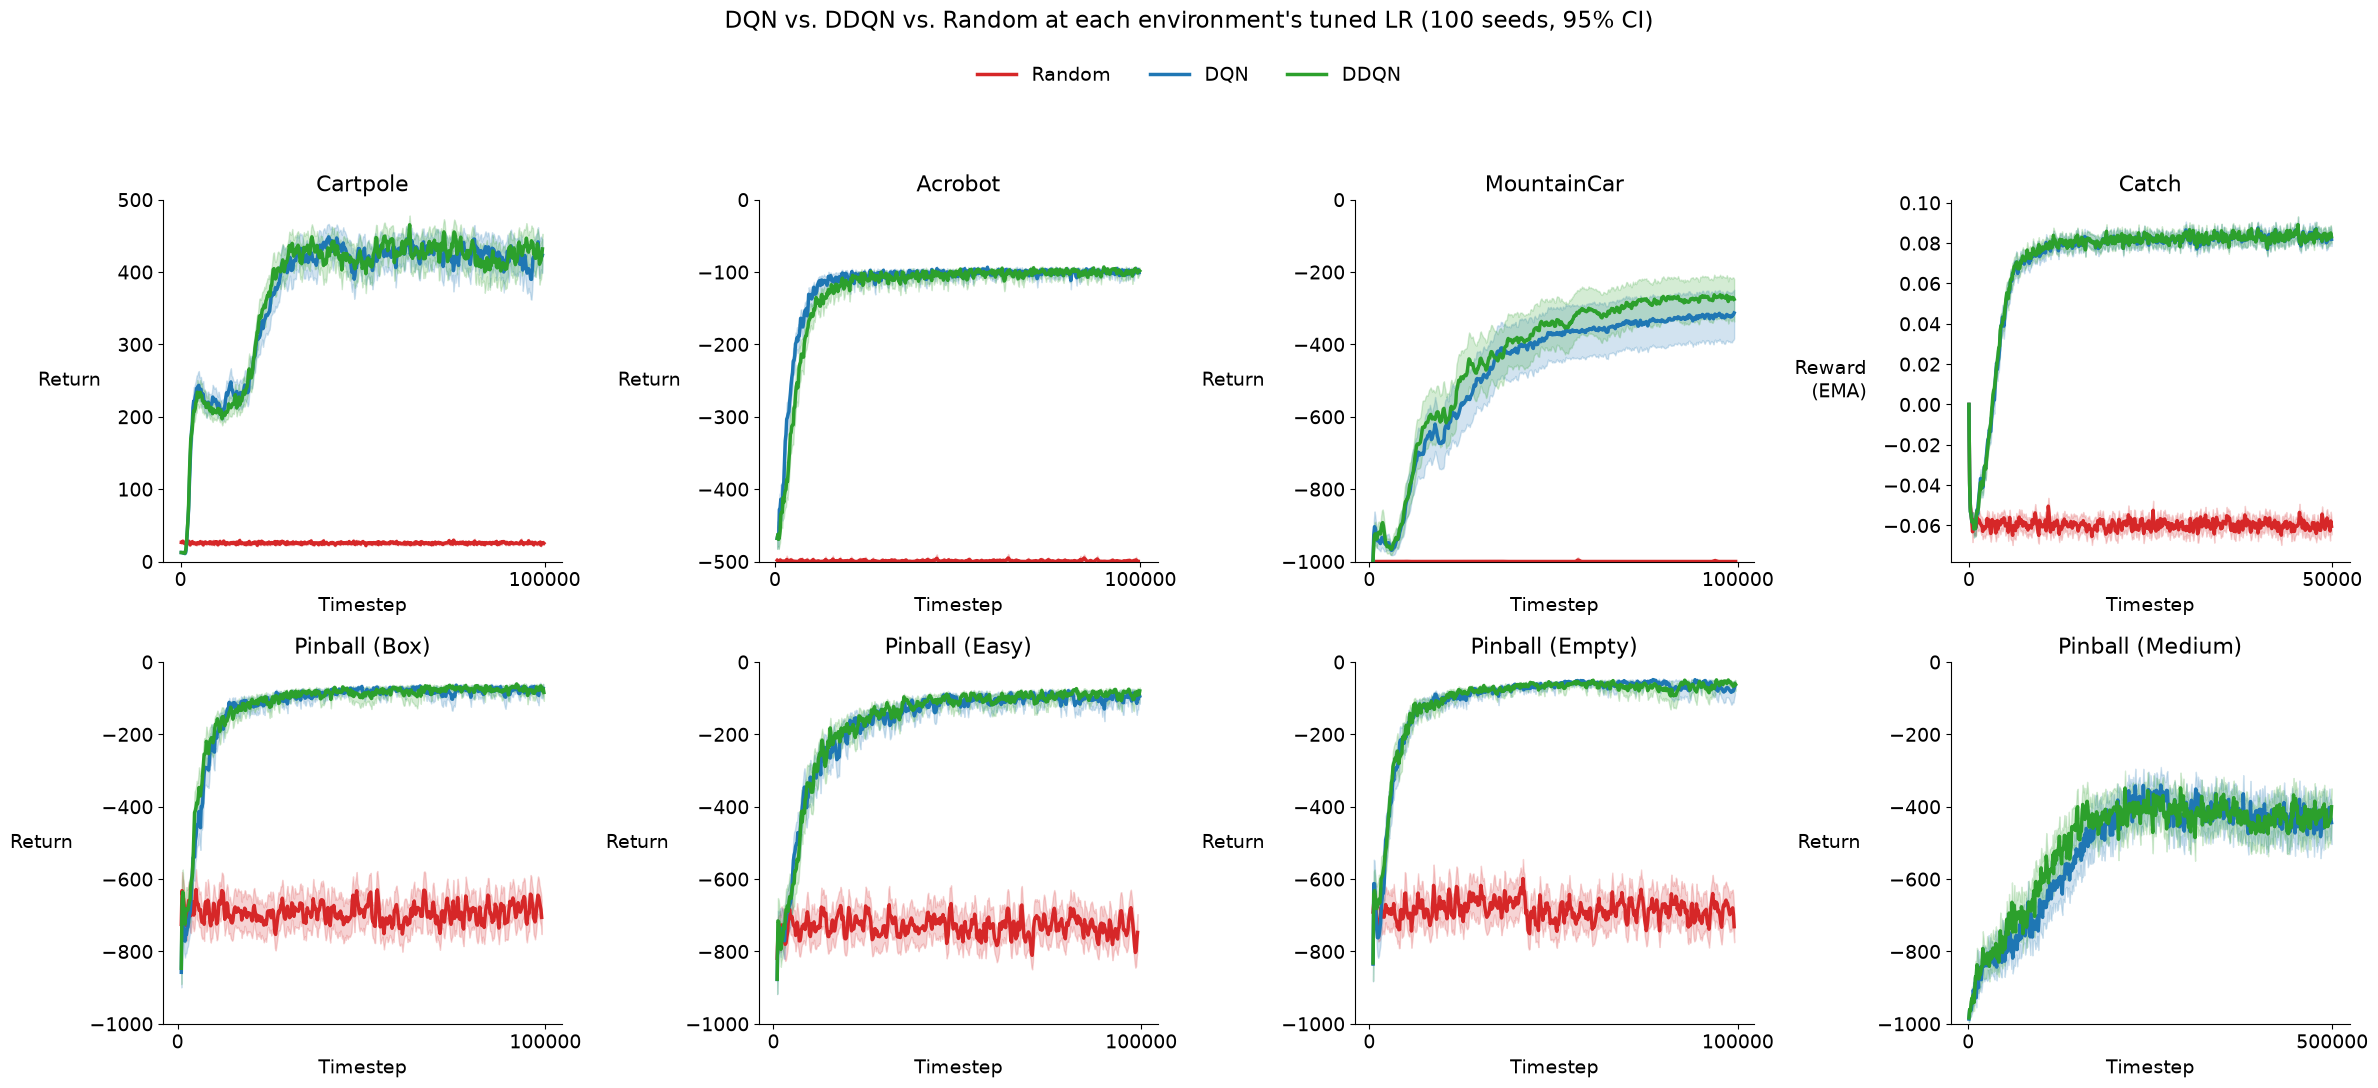

saved 9 plot(s) to /Users/parhammohammadpanahi/dev/online-gsp/experiments/tuned/plots


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
for ax, env in zip(axes.flat, ENVS, strict=True):
    series = load_series(env["key"], env["metric"])
    plot_series(ax, series)
    ylabel = "Return" if env["metric"] == "return" else "Reward\n(EMA)"
    ax.set_title(env["title"])
    style(ax, ylim=env["ylim"], ylabel=ylabel)
    set_timestep_xticks(ax, series)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.suptitle(
    "DQN vs. DDQN vs. Random at each environment's tuned LR (100 seeds, 95% CI)",
    y=0.99,
)
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
    ncol=3, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

fig.savefig(PLOTS_DIR / "grid_learning_curve.pdf", bbox_inches="tight")
print(f"saved {len(ENVS) + 1} plot(s) to {PLOTS_DIR}")